In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import ISLP
import statsmodels.formula.api as smf
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import statsmodels.api as sm
from sklearn.preprocessing import KBinsDiscretizer

In this exercise, you will further analyze the Wage data set considered
throughout this chapter.

year: Year that wage information was recorded

age: Age of worker

maritl: A factor with levels ‘1. Never Married’, ‘2. Married’, ‘3. ‘3. Widowed’, ‘4. Divorced’ and ‘5. Separated’ indicating marital status

race: A factor with levels ‘1. White’, ‘2. Black’, ‘3. Asian’ and ‘4. Other’ indicating race

education: A factor with levels ‘1. < HS Grad’, ‘2. HS Grad’, ‘3. Some College’, ‘4. College Grad’ and ‘5. Advanced Degree’ indicating education level

region: Region of the country (mid-atlantic only)

jobclass: A factor with levels ‘1. Industrial’ and ‘2. Information’ indicating type of job

health: A factor with levels ‘1. <=Good’ and ‘2. >=Very Good’ indicating health level of worker

health_ins: A factor with levels ‘1. Yes’ and ‘2. No’ indicating whether worker has health insurance

logwage: Log of workers wage

wage: Workers raw wage

In [14]:
df = ISLP.load_data('Wage')
print(df.info())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   year        3000 non-null   int64   
 1   age         3000 non-null   int64   
 2   maritl      3000 non-null   category
 3   race        3000 non-null   category
 4   education   3000 non-null   category
 5   region      3000 non-null   category
 6   jobclass    3000 non-null   category
 7   health      3000 non-null   category
 8   health_ins  3000 non-null   category
 9   logwage     3000 non-null   float64 
 10  wage        3000 non-null   float64 
dtypes: category(7), float64(2), int64(2)
memory usage: 115.5 KB
None


,year,age,logwage,wage
count,3000.000000,3000.000000,3000.000000,3000.000000
mean,2005.791000,42.414667,4.653905,111.703608
std,2.026167,11.542406,0.351753,41.728595
min,2003.000000,18.000000,3.000000,20.085537
25%,2004.000000,33.750000,4.447158,85.383940
50%,2006.000000,42.000000,4.653213,104.921507
75%,2008.000000,51.000000,4.857332,128.680488
max,2009.000000,80.000000,5.763128,318.342430


## (a) Perform polynomial regression to predict wage using age. Use cross-validation to select the optimal degree d for the polynomial. What degree was chosen, and how does this compare to the results of hypothesis testing using ANOVA? Make a plot of the resulting polynomial fit to the data.

### Use cross-validation to select the optimal degree d for the polynomial

In [15]:
X = df[['age']]
Y = df['wage']

best_degree = 0
best_score = float('inf')
cv_scores = []
degrees = range(1, 11)

for d in degrees:
    poly = PolynomialFeatures(degree=d, include_bias=False)
    X_poly = poly.fit_transform(X)
    model = LinearRegression()
    scores = cross_val_score(model, X_poly, Y, cv=10, scoring='neg_mean_squared_error')
    mean_mse = np.mean(-scores)
    cv_scores.append(mean_mse)
    
    if mean_mse < best_score:
        best_score = mean_mse
        best_degree = d

print(f'Best degree: {best_degree} with CV MSE: {best_score}')
print('CV MSE for each degree:', np.round(cv_scores, 2))

Best degree: 8 with CV MSE: 1592.8243475688737
CV MSE for each degree: [1675.67 1600.33 1595.31 1593.94 1594.48 1594.08 1593.   1592.82 1595.91
 1603.79]


### hypothesis testing using ANOVA

In [20]:
models = []
degrees = range(1, 15)

for d in degrees:
    # 構建公式字串，例如 d=2 時: "wage ~ age + I(age**2)"
    # I(...) 函式是 R-style 的語法，告訴 statsmodels 把裡面的運算當作一個特徵
    formula_parts = ['age'] + [f'I(age**{i})' for i in range(2, d+1)]
    formula = 'wage ~ ' + ' + '.join(formula_parts)
    
    # 擬合模型
    fit = smf.ols(formula, data=df).fit()
    models.append(fit)

# 3. 執行 ANOVA (Sequential F-test)
# *models 是解包操作，把列表中的 5 個模型模型拆開傳進去
anova_results = sm.stats.anova_lm(*models, typ=1)

print("--- Rigorous ANOVA Results (Sequential F-test) ---")
print(anova_results)

--- Rigorous ANOVA Results (Sequential F-test) ---
    df_resid           ssr  df_diff        ss_diff           F        Pr(>F)
0     2998.0  5.022216e+06      0.0            NaN         NaN           NaN
1     2997.0  4.793430e+06      1.0  228786.010128  136.203331  8.270440e-31
2     2996.0  4.777674e+06      1.0   15755.693664    9.379848  2.213330e-03
3     2995.0  4.771604e+06      1.0    6070.152124    3.613748  5.739975e-02
4     2994.0  4.770322e+06      1.0    1282.563017    0.763549  3.822902e-01
5     2993.0  4.766389e+06      1.0    3932.257442    2.340993  1.261148e-01
6     2993.0  4.764599e+06     -0.0    1790.485646        -inf           NaN
7     2993.0  4.764136e+06     -0.0     462.454496        -inf           NaN
8     2993.0  4.764981e+06     -0.0    -844.187374         inf           NaN
9     2993.0  4.780664e+06     -0.0  -15682.924317         inf           NaN
10    2993.0  4.779592e+06     -0.0    1071.456841        -inf           NaN
11    2992.0  4.779304e+0

## plot

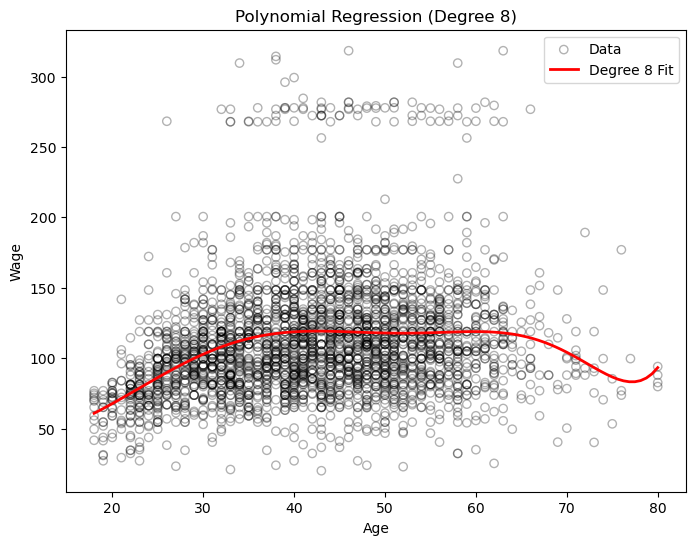

In [19]:
plt.figure(figsize=(8, 6))
plt.scatter(df['age'], df['wage'], facecolor='None', edgecolor='k', alpha=0.3, label='Data')

# 產生平滑的預測線
age_grid = np.linspace(df['age'].min(), df['age'].max(), 100).reshape(-1, 1)
poly_best = PolynomialFeatures(degree=best_degree, include_bias=False)
X_grid_poly = poly_best.fit_transform(age_grid)

# 用最佳 degree 重新訓練一次全資料模型
final_model = LinearRegression().fit(poly_best.fit_transform(X), Y)
y_pred = final_model.predict(X_grid_poly)

plt.plot(age_grid, y_pred, color='red', linewidth=2, label=f'Degree {best_degree} Fit')
plt.title(f'Polynomial Regression (Degree {best_degree})')
plt.xlabel('Age')
plt.ylabel('Wage')
plt.legend()
plt.show()

### Cross-validation selected degree 8 as the optimal model. However, the ANOVA analysis indicates that any improvement beyond degree 3 is not statistically significant.

# (b) Fit a step function to predict wage using age, and perform cross-validation to choose the optimal number of cuts. Make a plot of the fit obtained.


CV 選擇的最佳 Cuts 數量是: 16


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KBinsDiscretizer was fitted with feature names
  warnings.warn(


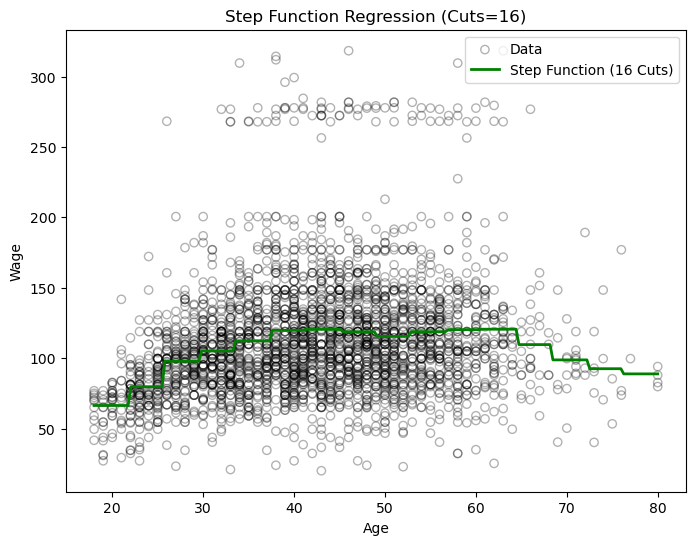

In [24]:
# --- 步驟 1: Cross-Validation 選擇最佳 Cuts ---
best_cuts = 0
best_score_cuts = float('inf')
cv_scores_cuts = []
cut_range = range(2, 21) # 測試切 2 份到 10 份

for c in cut_range:
    # 這是把 age 變成 c 個區間，並轉成 One-Hot Encoding (Dummy Variables)
    # 這樣 LinearRegression 就會針對每個區間算出一個平均薪資常數
    discretizer = KBinsDiscretizer(n_bins=c, encode='onehot-dense', strategy='uniform')
    X_binned = discretizer.fit_transform(X)
    
    model = LinearRegression()
    scores = -cross_val_score(model, X_binned, Y, cv=10, scoring='neg_mean_squared_error')
    mean_mse = np.mean(scores)
    cv_scores_cuts.append(mean_mse)
    
    if mean_mse < best_score_cuts:
        best_score_cuts = mean_mse
        best_cuts = c

print(f"\nCV 選擇的最佳 Cuts 數量是: {best_cuts}")

# --- 步驟 2: 繪圖 ---
plt.figure(figsize=(8, 6))
plt.scatter(df['age'], df['wage'], facecolor='None', edgecolor='k', alpha=0.3, label='Data')

# 建立最佳模型
discretizer_final = KBinsDiscretizer(n_bins=best_cuts, encode='onehot-dense', strategy='uniform')
X_binned_final = discretizer_final.fit_transform(X)
final_step_model = LinearRegression().fit(X_binned_final, Y)

# 預測用的網格 (為了畫出階梯效果)
age_grid = np.linspace(df['age'].min(), df['age'].max(), 200).reshape(-1, 1)
age_grid_binned = discretizer_final.transform(age_grid)
y_step_pred = final_step_model.predict(age_grid_binned)

plt.plot(age_grid, y_step_pred, color='green', linewidth=2, label=f'Step Function ({best_cuts} Cuts)')
plt.title(f'Step Function Regression (Cuts={best_cuts})')
plt.xlabel('Age')
plt.ylabel('Wage')
plt.legend()
plt.show()